# 5 · Lab: Hong–Ou–Mandel Interference

**Simulation lab, part 1 · Wednesday July 29, 10:30–11:30 · work in pairs**

Today you run linear-optical experiments on a simulated photonic quantum processor, using **Perceval** [Heurtel2023] — the same framework used to program Quandela's real photonic quantum computers. The physics star of this session is the **Hong–Ou–Mandel (HOM) effect** [Hong1987]: two indistinguishable photons meeting on a beamsplitter *always leave together*.

### Learning objectives

1. build and sample a linear-optical circuit in Perceval,
2. predict and verify the two-photon output of a 50:50 beamsplitter,
3. simulate a **HOM dip** and extract its visibility.

*Review reading: [Bouchard2021] in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("perceval") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                           "perceval-quandela"])

import numpy as np
import matplotlib.pyplot as plt
import perceval as pcvl

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
print("perceval", pcvl.__version__)

# Crisp plots on projectors and HiDPI screens (works on Colab too).
%config InlineBackend.figure_format = "retina"

perceval 1.2.4


## Perceval in 10 minutes

Perceval describes experiments the way an optics lab does:

| concept | Perceval object | example |
|---|---|---|
| photons entering the chip | `BasicState` | `pcvl.BasicState([1, 1])` — one photon in each of 2 modes |
| the optical circuit | `Circuit` + components | `pcvl.BS()` (beamsplitter), `pcvl.PS(phi)` (phase shifter) |
| the machine that runs it | `Processor` | `pcvl.Processor("SLOS", circuit)` |
| taking data | `Sampler` | `sampler.probs()` or `sampler.sample_count(N)` |

A *mode* is one path on the chip (it could also be a polarization or a time bin). `|1,1⟩` means "one photon in the top mode, one in the bottom mode". Let's start with the simplest quantum experiment there is: **one photon on a beamsplitter.**

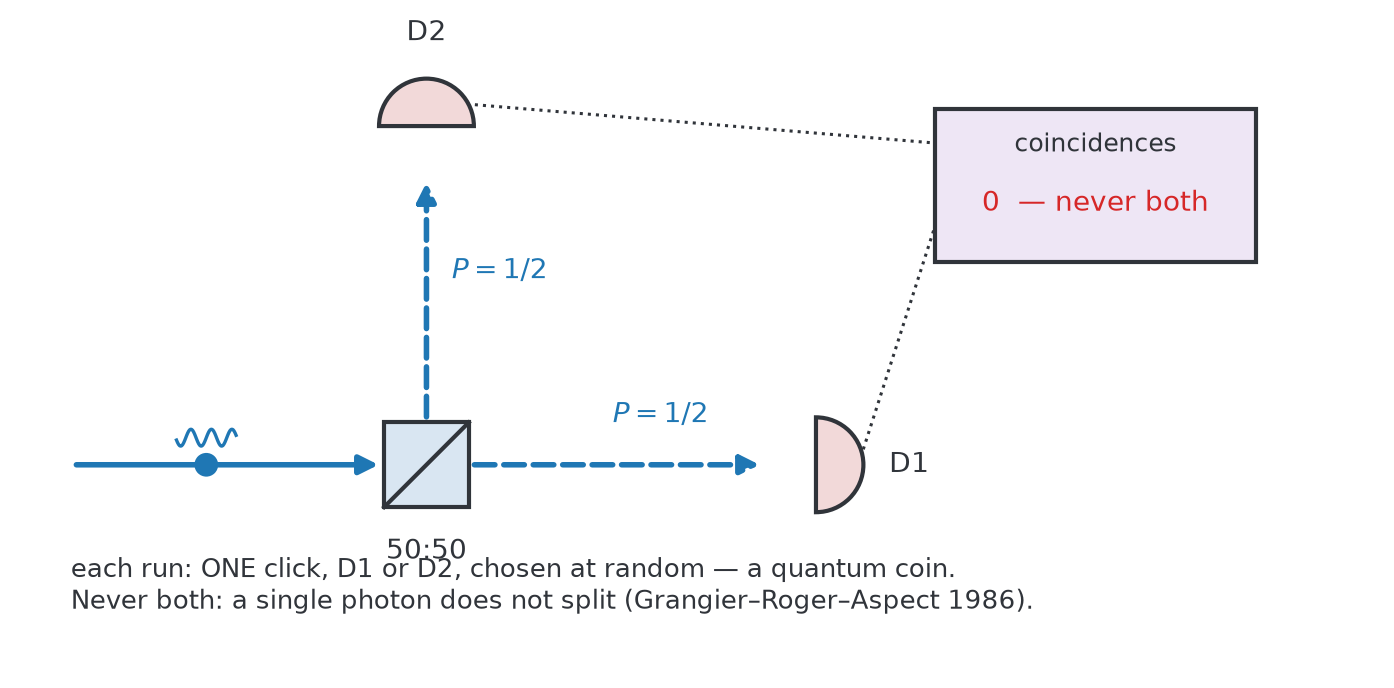

In [2]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.single_photon_bs()

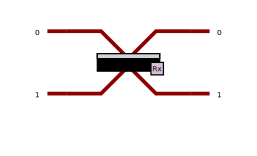

In [3]:
# One photon, one 50:50 beamsplitter.
circuit = pcvl.Circuit(2) // pcvl.BS()      # 2 modes, one beamsplitter
pcvl.pdisplay(circuit)

In [4]:
processor = pcvl.Processor("SLOS", circuit)    # SLOS = exact simulation backend
processor.with_input(pcvl.BasicState([1, 0]))  # photon enters the top mode
processor.min_detected_photons_filter(1)       # keep events with >= 1 detected photon

sampler = pcvl.algorithm.Sampler(processor)
probs = sampler.probs()["results"]
print("exact output probabilities:")
for state, p in probs.items():
    print(f"  {state}: {p:.3f}")

# ... and what actual repeated single-shot measurements look like:
counts = sampler.sample_count(1000)["results"]
print("\n1000 samples (clicks!):")
for state, c in counts.items():
    print(f"  {state}: {c}")

exact output probabilities:
  |0,1>: 0.500
  |1,0>: 0.500

1000 samples (clicks!):
  |1,0>: 502
  |0,1>: 498


50/50 — each *single* photon takes one output or the other at random (this randomness is quantum: it is the shot noise you met on Monday). So far a classical coin would explain the data.

## One photon interferes with itself (Taylor 1909)

Before the two-photon magic, re-run the **oldest quantum-optics experiment there is**. In 1909, G.I. Taylor — on Thomson's suggestion — photographed diffraction fringes using light attenuated until, by his estimate, at most one quantum was in flight at a time (exposure: three months; light level: "a candle burning at a distance slightly exceeding a mile") [Taylor1909]. The fringes survived: *a single photon interferes with itself.*

Our chip version of "two slits" is the **Mach–Zehnder interferometer**: split one photon, phase-shift one path by $\varphi$, recombine:

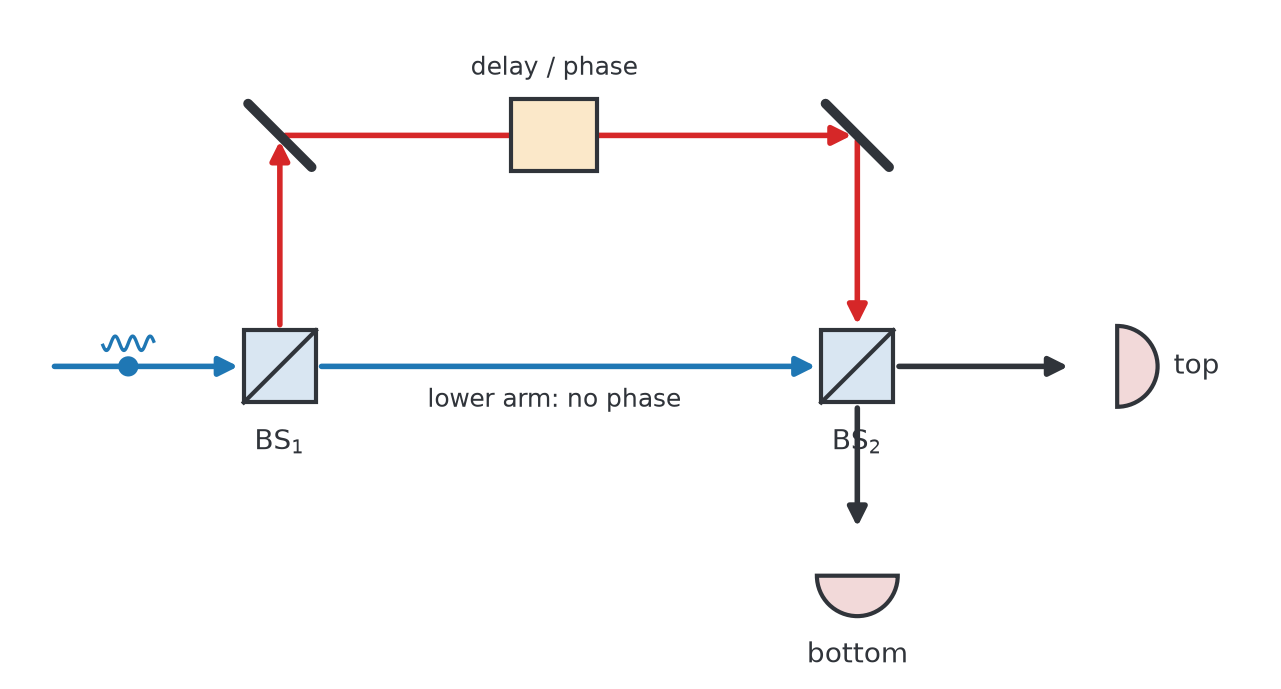

In [5]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.mzi_sketch()

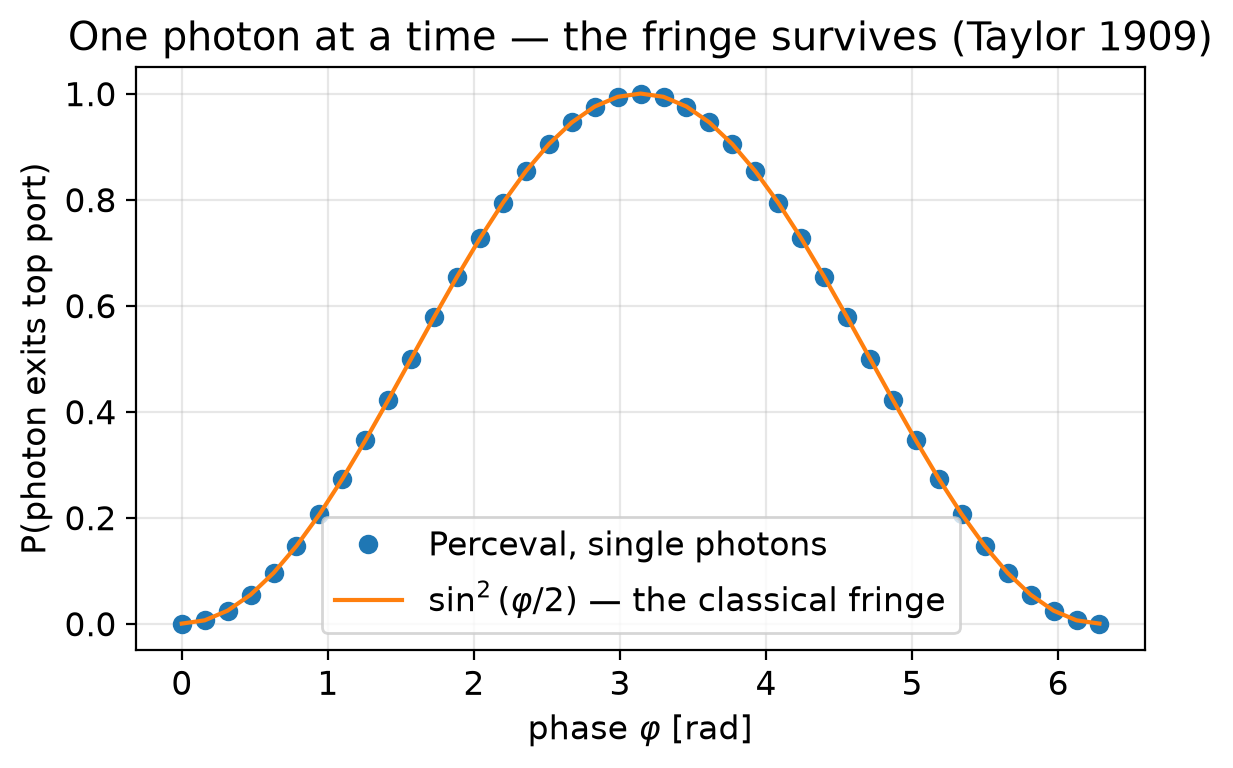

In [6]:
# Taylor 1909, integrated-optics edition: single-photon MZI fringes.
def mzi(phi: float) -> pcvl.Circuit:
    """Mach-Zehnder interferometer: BS - phase phi in the top arm - BS."""
    return pcvl.Circuit(2) // pcvl.BS() // (0, pcvl.PS(phi)) // pcvl.BS()

phis = np.linspace(0, 2 * np.pi, 41)
p_top = []
for phi in phis:
    proc = pcvl.Processor("SLOS", mzi(phi))
    proc.with_input(pcvl.BasicState([1, 0]))       # ONE photon
    proc.min_detected_photons_filter(1)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_top.append(res.get(pcvl.BasicState([1, 0]), 0.0))

plt.plot(phis, p_top, "o", label="Perceval, single photons")
plt.plot(phis, np.sin(phis / 2) ** 2, "-",
         label=r"$\sin^2(\varphi/2)$ — the classical fringe")
plt.xlabel(r"phase $\varphi$ [rad]")
plt.ylabel("P(photon exits top port)")
plt.title("One photon at a time — the fringe survives (Taylor 1909)")
plt.legend()
plt.tight_layout()
plt.show()

Each run detects **one** click, top *or* bottom — never half a photon in each. Only the *statistics* over many runs trace the fringe, and it follows the classical intensity formula exactly. Single-photon ("first-order") interference reproduces classical interference — nothing here needs photons at all, as the wave theory happily explains this experiment. Hold that thought for Exercise 3.

## The HOM effect: now send in TWO photons

Input $|1,1\rangle$ — one photon in each input port, perfectly indistinguishable. Classical intuition says: each picks a side independently, so 50% of the time they exit on *different* sides (a coincidence).

Quantum mechanics says: the two paths to a coincidence — *both transmit* and *both reflect* — are indistinguishable processes, so their **amplitudes** add. For a 50:50 beamsplitter they cancel *exactly*:

$$P_{\rm coinc} = |t\cdot t - r\cdot r|^2 = \left|\tfrac12 - \tfrac12\right|^2 = 0 .$$

(The minus sign is the beamsplitter's unitarity speaking: the reflected amplitude carries a phase $i$, and $i^2 = -1$.)

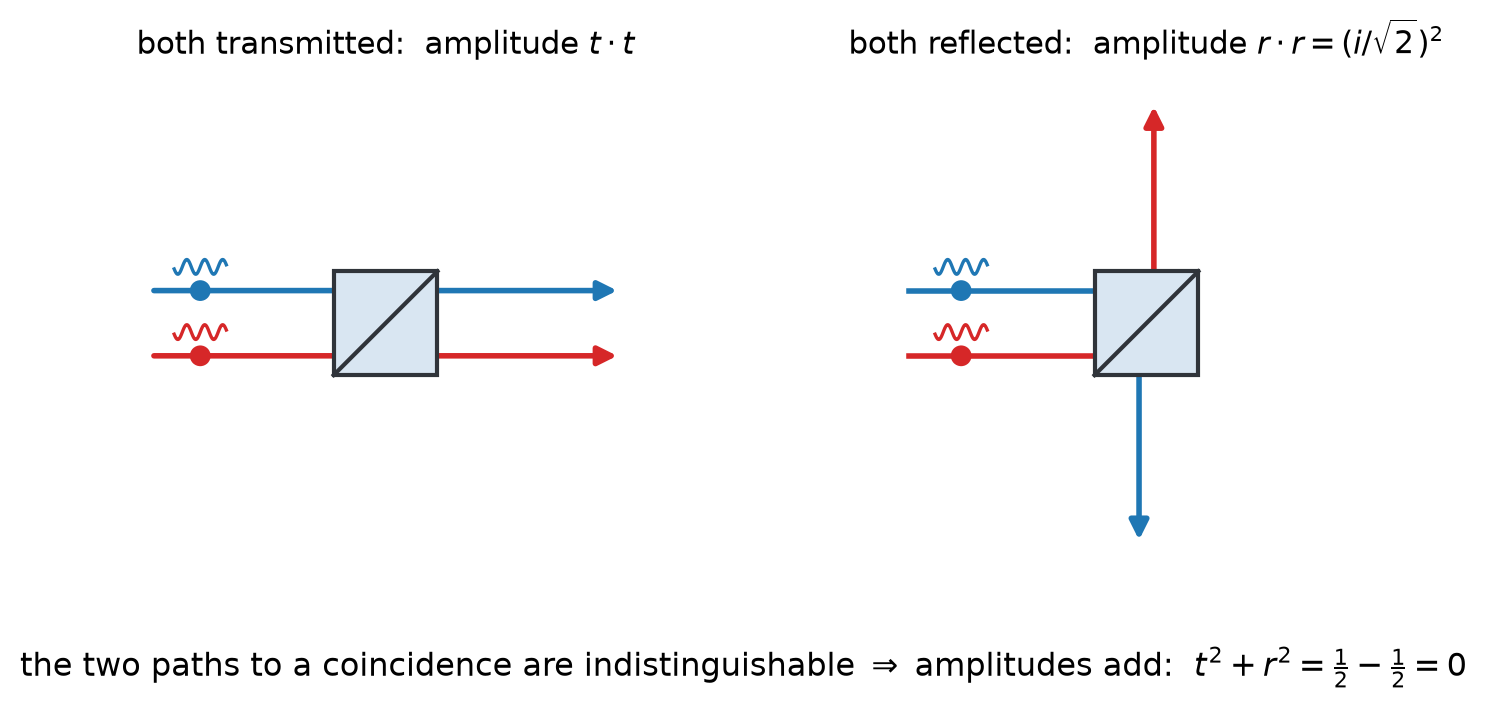

In [7]:
sketches.hom_amplitudes()

In [8]:
# HOM: two indistinguishable photons on the 50:50 beamsplitter.
processor = pcvl.Processor("SLOS", circuit)
processor.with_input(pcvl.BasicState([1, 1]))
processor.min_detected_photons_filter(2)

probs = pcvl.algorithm.Sampler(processor).probs()["results"]
print("two-photon output probabilities:")
for state, p in probs.items():
    print(f"  {state}: {p:.3f}")

two-photon output probabilities:
  |0,2>: 0.500
  |2,0>: 0.500


**The photons bunch:** always $|2,0\rangle$ or $|0,2\rangle$, *never* $|1,1\rangle$. No coincidences — this is not interference of intensities (it survives any phase between the inputs), it is interference of **two-photon amplitudes**. It only happens because the photons are fully indistinguishable bosons.

## Exercise 1 · Unbalancing the beamsplitter

For a beamsplitter with reflectivity $R$ (and $T = 1-R$), the coincidence probability for $|1,1\rangle$ input is

$$P_{\rm coinc}(R) = (T - R)^2 = (1 - 2R)^2 .$$

**Task:** verify this with Perceval. Scan $R$ from 0 to 1 (say 21 points), get $P(|1,1\rangle)$ at the output for each, plot the simulation as points and the formula as a line.

*API hint:* a beamsplitter with a given reflectivity is `pcvl.BS(theta=pcvl.BS.r_to_theta(R))`.

In [9]:
# YOUR CODE HERE - Exercise 1
R_values = np.linspace(0, 1, 21)


## Exercise 2 · The HOM dip

In the lab you can't just declare photons indistinguishable — you *tune* their overlap, classically, by sliding a delay line: photons that arrive at very different times are perfectly distinguishable (no interference), photons that arrive simultaneously interfere fully. Scanning the delay $\delta\tau$ traces out the famous **HOM dip** in the coincidence rate.

For photons with Gaussian wavepackets of coherence time $\tau_c$, the *indistinguishability* (mode overlap squared) is

$$\mathcal{I}(\delta\tau) = e^{-(\delta\tau/\tau_c)^2},$$

and the coincidence probability at a 50:50 beamsplitter becomes

$$P_{\rm coinc}(\delta\tau) = \tfrac12\left(1 - \mathcal{I}(\delta\tau)\right).$$

In Perceval, partial distinguishability is a property of the photon *source*, set through the noise model:

```python
processor = pcvl.Processor("SLOS", circuit,
                           noise=pcvl.NoiseModel(indistinguishability=I))
```

**Task:**
1. sweep $\mathcal{I}$ from 0 to 1 and record $P(|1,1\rangle)$ — confirm $P = (1-\mathcal{I})/2$;
2. convert to a dip: plot $P_{\rm coinc}$ versus delay $\delta\tau/\tau_c \in [-3, 3]$ using the Gaussian mapping;
3. compute the **visibility** $V = \frac{P_{\max} - P_{\min}}{P_{\max}}$ of your dip. What is $V$ for perfectly indistinguishable photons? What would $V = 0.5$ tell you about a photon-pair source?

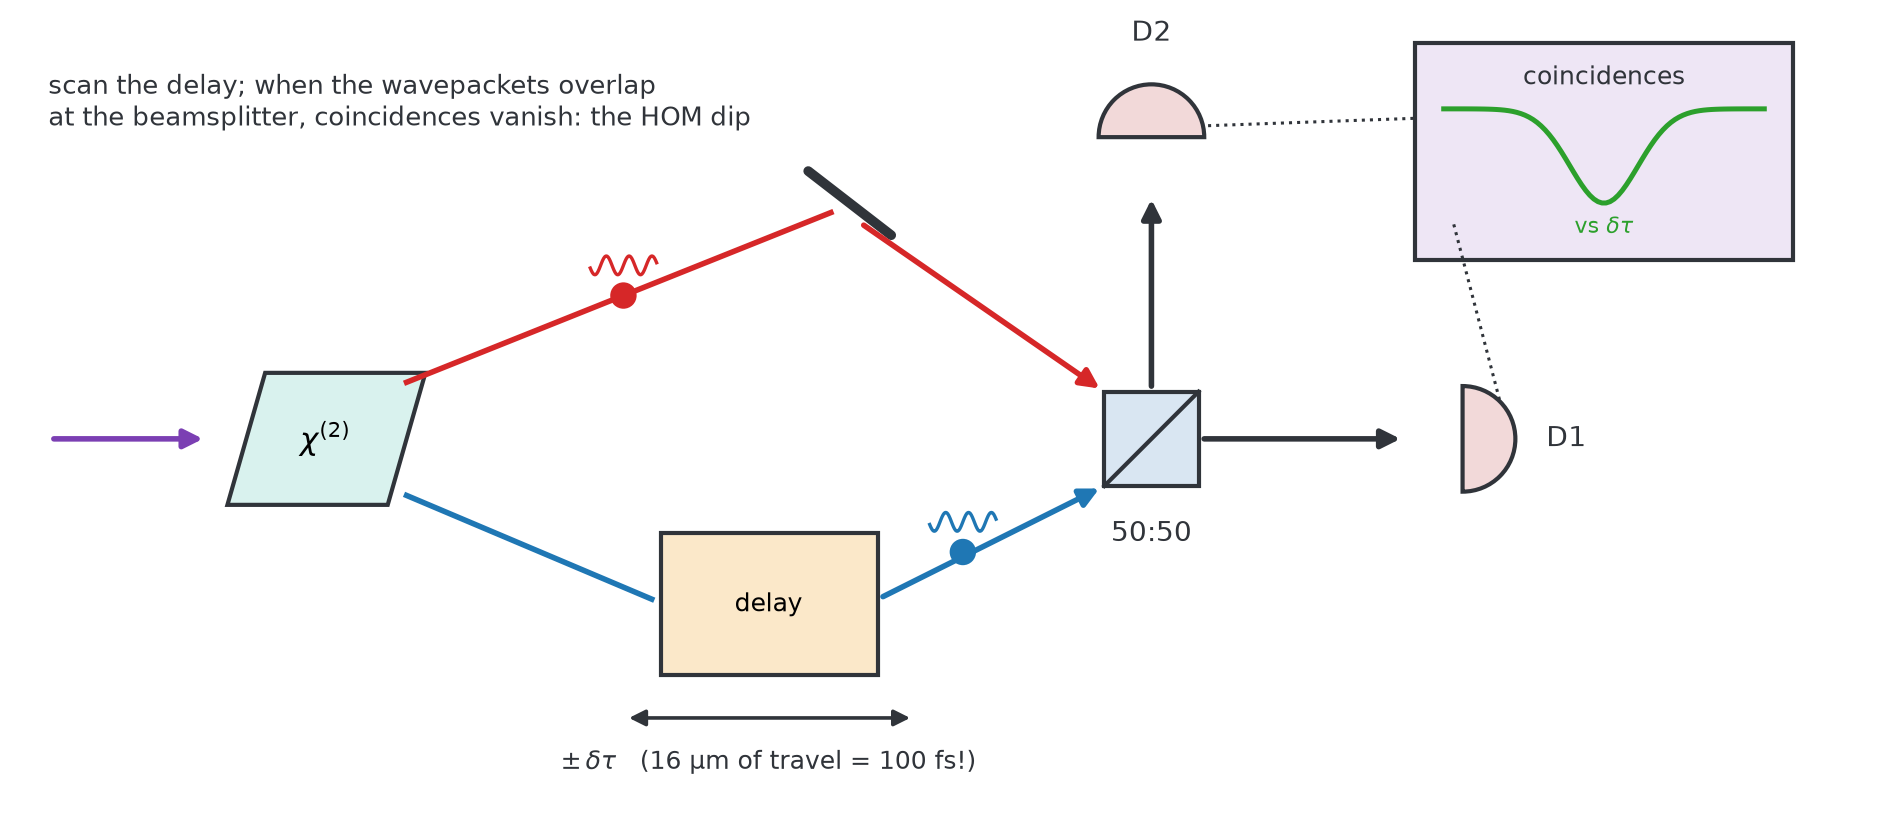

In [10]:
sketches.hom_dip_setup()

In [11]:
# YOUR CODE HERE - Exercise 2
indistinguishability_values = np.linspace(0, 1, 11)


## Exercise 3 · Two-photon interference has no phase

The claim from the whiteboard: HOM is interference of *two-photon amplitudes*, not of fields. Test it the way an experimentalist would:

1. Take the HOM setup (|1,1⟩ into a 50:50 BS) and insert a phase shifter `pcvl.PS(phi)` in **one input arm**, before the beamsplitter. Scan $\varphi$ from 0 to $2\pi$ and plot the coincidence probability.
2. Compare with the single-photon MZI fringe from the Taylor section (same phase scan!).
3. Explain the difference in one sentence, thinking about *which* two paths interfere in each case — and why the HOM paths both acquire the *same* phase.

*Lab relevance:* this is exactly how you distinguish genuine two-photon interference from residual classical (first-order) interference in a noisy setup — wiggle a mirror; if the coincidence rate wiggles, it wasn't HOM.

In [12]:
# YOUR CODE HERE - Exercise 3
phis = np.linspace(0, 2 * np.pi, 21)


### Interlude · Why quantum-light experiments don't need phase stability

Exercise 3's flat line is not a technicality — it is **number–phase complementarity** doing you an enormous experimental favor.

Photon number and phase are conjugate: $\Delta n\,\Delta\varphi \gtrsim 1$. A Fock state has *definite* $n$ and therefore **no phase at all** — recall Monday's Wigner function of $|4\rangle$: perfectly rotation-symmetric rings, no preferred direction in phase space. If the states you send in carry no phase, and the quantities you record are photon-counting correlations ($g^{(2)}$, coincidences, HOM dips), then *there is no optical phase anywhere in the experiment for you to stabilize.*

The practical consequences, by experiment class:

| experiment | interferes | path stability needed |
|---|---|---|
| MZI / Michelson fringes (Taylor section) | field amplitudes, $e^{i\varphi}$ | $\ll \lambda$ — nanometers, active locking |
| **HBT** (yesterday) | intensities | *none* — that's why Narrabri worked through the atmosphere |
| **HOM** (today) | two-photon amplitudes | only within the **coherence length** (µm–mm) — so the wavepackets overlap, not so phases align |
| homodyne / squeezing (LIGO, Monday) | signal *against a phase reference* | $\ll\lambda$ again — squeezed light *is* phase-structured |

This is why a HOM dip runs unstabilized overnight while a classical white-light interferometer drifts away in seconds, and why photon counting is the natural language of Fock-state optics: by *not* bringing a phase reference (no local oscillator), you measure exactly the phase-free observables the states actually possess. The flip side: the moment your quantum trick involves phase-structured states — squeezing, NOON states (next exercise!) — the interferometric stability bill returns, with interest.

### Visibility · the fine print

Since the HOM dip has no fringes, its quality is a **contrast**, not a phase:

$$V = \frac{P_{\rm coinc}^{\max} - P_{\rm coinc}^{\min}}{P_{\rm coinc}^{\max}} \;\xrightarrow{\text{50:50 BS}}\; 1 - 2\,P_{\rm coinc}(0).$$

Three facts to carry into any lab or paper:

* **$V$ *is* the indistinguishability.** For pure single photons, $V = \mathcal{I} = |\langle\psi_1|\psi_2\rangle|^2$ — the dip is a direct meter of wavepacket overlap (your Exercise 2 showed the linear relation). Mismatch in *any* degree of freedom — arrival time, spectrum, polarization, spatial mode — is a factor $<1$.
* **$V > 1/2$ is the quantum certificate.** Two independent *classical* pulses with randomized relative phase also show a coincidence dip — but at most to half depth: $V_{\rm cl} \le 1/2$. Beating 1/2 plays the same role for two-photon interference that $g^{(2)}(0) < 1$ plays for antibunching. (Yet another reason 50%-ish visibilities in old or noisy experiments prove nothing quantum.)
* **Raw vs. corrected.** Real dips are eaten by multi-photon emission (each source's own $g^{(2)}(0) > 0$!), background counts, and accidentals. Papers quote *raw* visibility (as measured) or *corrected* (backgrounds/multi-photon subtracted) — the gap between them can be tens of percent. When a source claims $V > 95\%$, always check which one it is [Bouchard2021].

## Exercise 4 · The NOON state: a phase measured twice as fast

Look again at the HOM output state: $(|2,0\rangle - |0,2\rangle)/\sqrt2$ — "2 photons here, superposed with 2 photons there." This is a **NOON state** with $N = 2$, and it is a metrology resource: the two-photon amplitude picks up phase at *twice* the single-photon rate ($e^{i2\varphi}$ instead of $e^{i\varphi}$).

**Task:** build the full MZI (`BS`, then `PS(phi)` on the top arm, then `BS`) and send in $|1,1\rangle$ — so the HOM effect creates the NOON state right at the first beamsplitter.

1. Plot the *coincidence* probability $P(|1,1\rangle_{\rm out})$ vs $\varphi$;
2. overlay the single-photon fringe from the Taylor section;
3. extract the fringe period: you should find **half** — oscillation as $\cos 2\varphi$. This is *super-resolution*: the $N$-photon NOON state does phase metrology at the $1/N$ Heisenberg scale rather than the $1/\sqrt{N}$ shot-noise scale. (LIGO's squeezing from Monday is this same idea's more scalable cousin.)

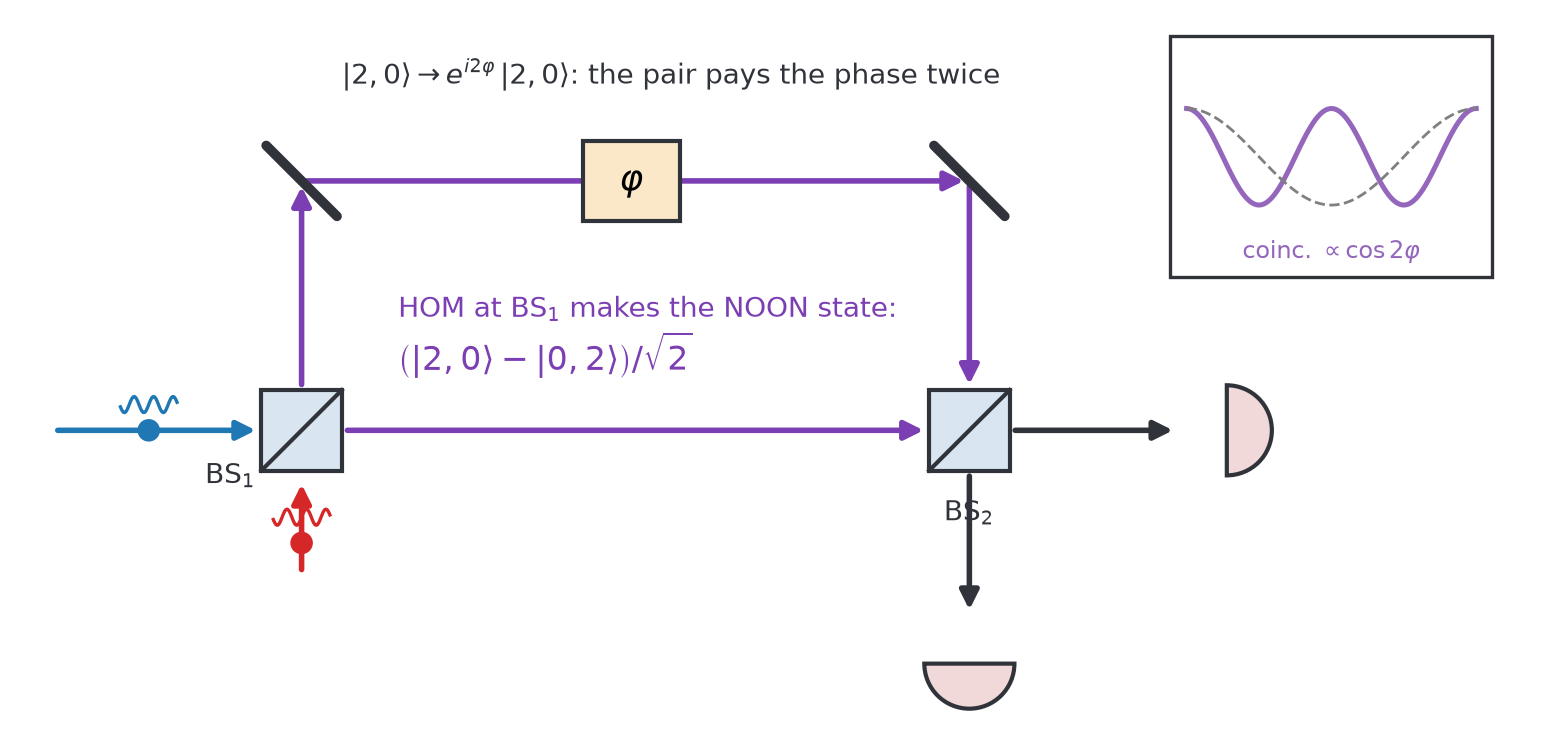

In [13]:
sketches.noon_mzi()

In [14]:
# YOUR CODE HERE - Exercise 4
phis = np.linspace(0, 2 * np.pi, 41)


## If you finish early

* Three-mode challenge: build a *tritter* (3-mode balanced splitter: `pcvl.Circuit(3)` with three `BS`/`PS` — or `pcvl.GenericInterferometer`) and find the three-photon analog of HOM suppression for $|1,1,1\rangle$.
* Sampling realism: replace `probs()` by `sample_count(200)` in your HOM dip and re-extract the visibility — now with shot noise. How many samples per point do you need to certify $V > 0.9$?

## Why this matters (5-minute wrap-up before the break)

**A bit of history first.** Hong, Ou and Mandel built the experiment in 1987 to measure the time interval between two photons with **sub-picosecond** resolution [Hong1987] — decades before electronics could dream of it: the dip width in *delay* is set by the photon coherence time, so a mechanical translation stage becomes a femtosecond clock. Their measured dip: ~100 fs wide (16 µm of beamsplitter travel!), coincidences dropping to a few percent of the wing level — the residual floor set not by the beamsplitter (R/T ≈ 0.95) but by imperfect signal–idler mode overlap at the pinholes. Mode matching has been the experimentalist's tax on HOM visibility ever since. Today the HOM dip is:

* ***the* benchmark of single-photon sources**: the first quantum-dot HOM experiment reached a mean wavepacket overlap of 0.81 [Santori2002]; today's best dots deliver raw two-photon visibilities above 90–95% — the first number to check in any source paper [Bouchard2021];
* **the working principle of every two-qubit gate in linear-optical quantum computing**: photons that don't HOM don't compute. The 2020 boson-sampling quantum advantage [Zhong2020] is, at heart, dozens of photons (43 detected on average) HOM-interfering in a 100-mode interferometer;
* **a metrology resource, twice over**: the NOON fringes of your Exercise 4, and the dip itself as a ruler — broadband photons whose first-order fringes died femtoseconds ago still carry **attosecond-resolution** timing in their coincidence visibility, with zero phase stabilization [Lyons2018] (ruler #3 of Monday's case study); plus a synchronization tool for quantum networks — HOM dips between photons from *different remote sources* certify that network nodes are interferometrically aligned;
* **still a testbed for quantum mechanics itself**: with UB colleagues — including this school's co-organizer Herbert Fotso — we proposed using photon-number states at a beamsplitter to hunt for tiny deviations from Born-rule statistics [Powers2025]. Two mirrors and a piece of glass, and the foundations are still in play.

After the break: we stop *assuming* single photons and *make* them — [`06_Lab_HeraldedFockStates`](06_Lab_HeraldedFockStates.ipynb).

---
---

# Sample solutions

**No peeking during the session.**

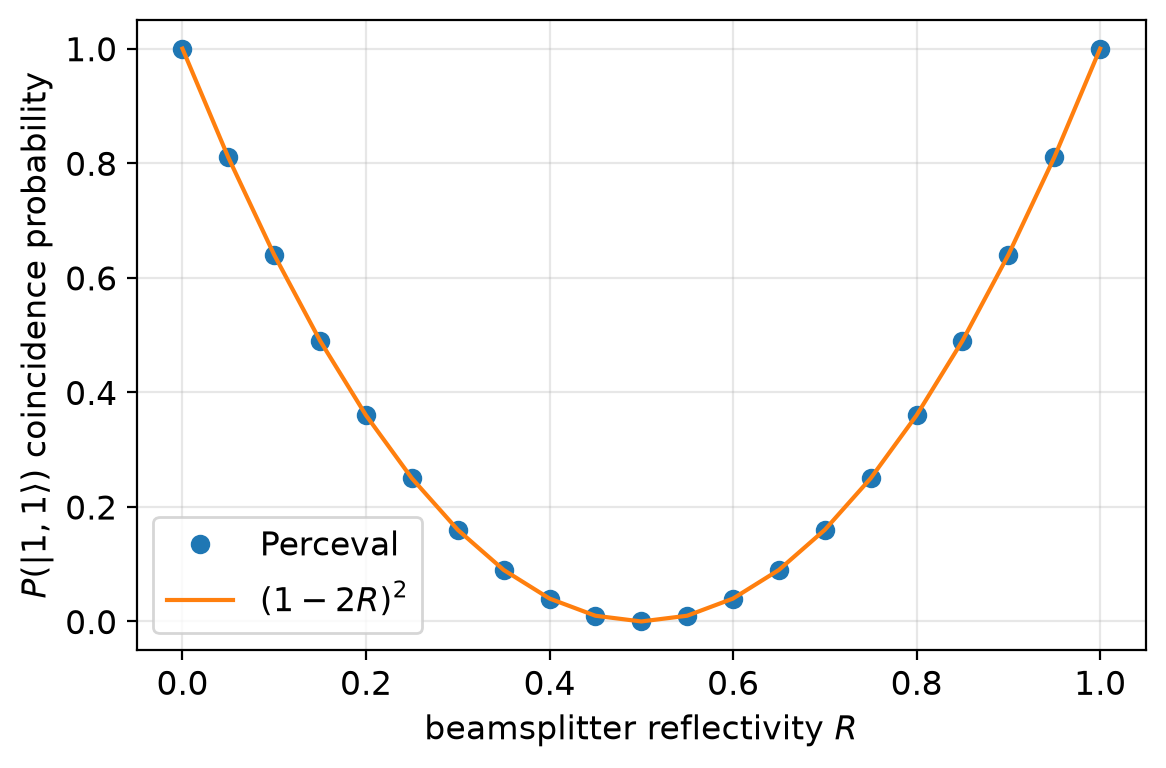

In [15]:
# Solution - Exercise 1
R_values = np.linspace(0, 1, 21)
p_coinc = []
for R in R_values:
    c = pcvl.Circuit(2) // pcvl.BS(theta=pcvl.BS.r_to_theta(R))
    proc = pcvl.Processor("SLOS", c)
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(res.get(pcvl.BasicState([1, 1]), 0.0))

plt.plot(R_values, p_coinc, "o", label="Perceval")
plt.plot(R_values, (1 - 2 * R_values) ** 2, "-", label="$(1-2R)^2$")
plt.xlabel("beamsplitter reflectivity $R$")
plt.ylabel(r"$P(|1,1\rangle)$ coincidence probability")
plt.legend(); plt.tight_layout(); plt.show()

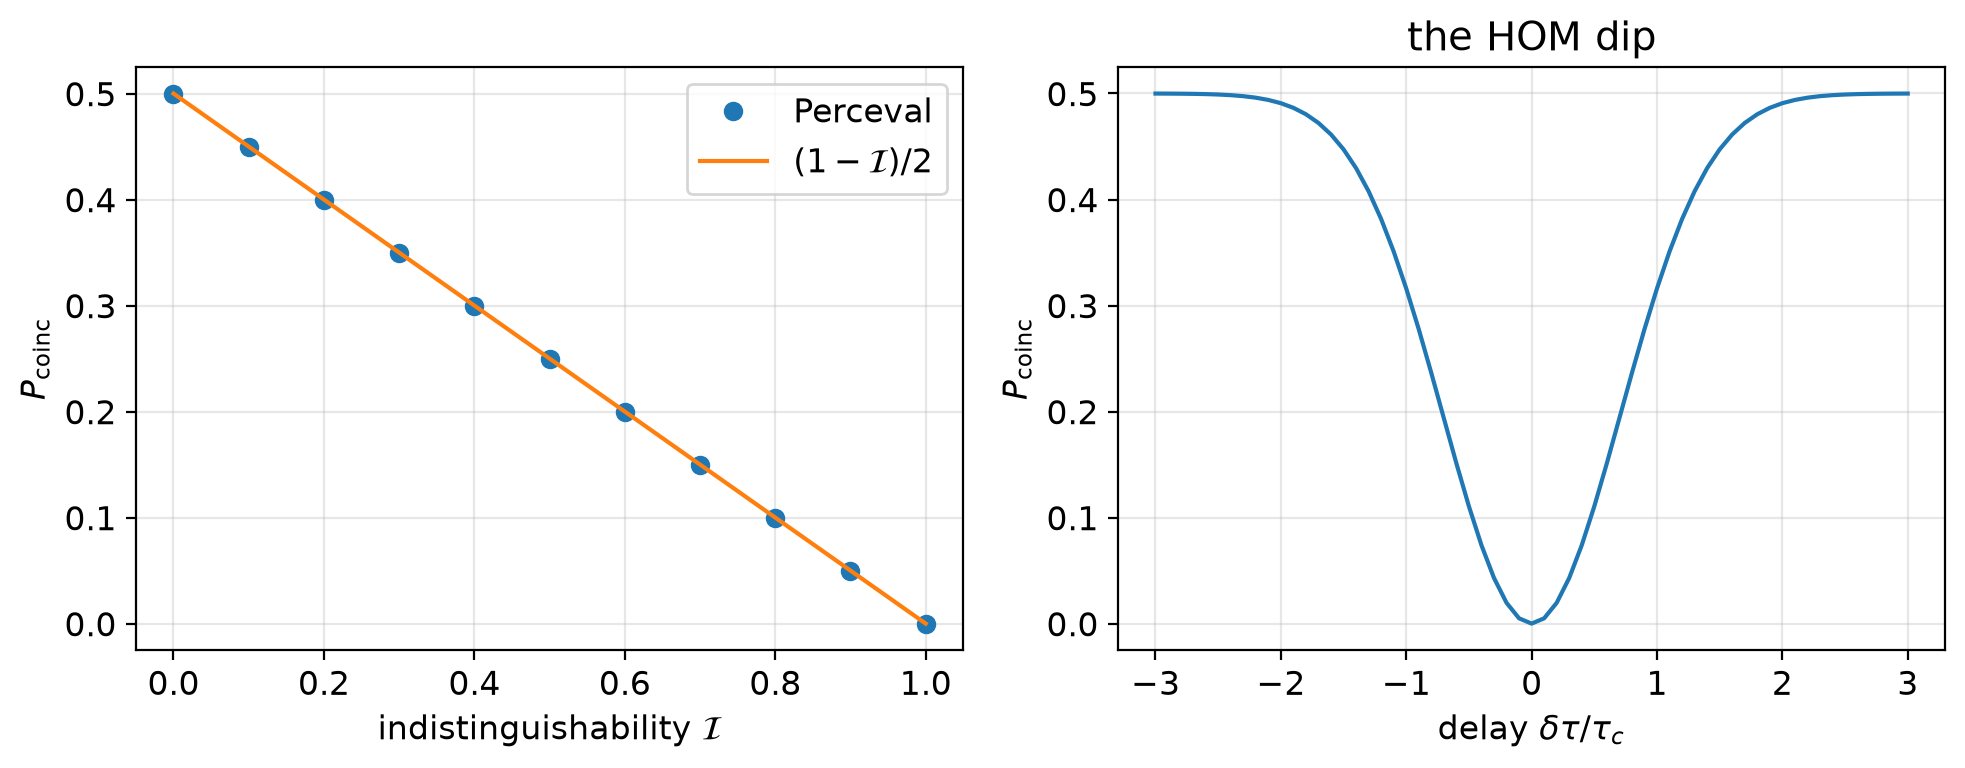

dip visibility V = 1.000
V = 1 for perfectly indistinguishable photons;
V = 0.5 is the classical limit for intensity-correlated fields -
a source with V = 0.5 shows no quantum interference at all.


In [16]:
# Solution - Exercise 2
circuit = pcvl.Circuit(2) // pcvl.BS()

# (1) coincidences vs indistinguishability
I_values = np.linspace(0, 1, 11)
p_coinc = []
for I in I_values:
    proc = pcvl.Processor("SLOS", circuit,
                          noise=pcvl.NoiseModel(indistinguishability=I))
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(sum(p for st, p in res.items()
                       if st[0] == 1 and st[1] == 1))
p_coinc = np.array(p_coinc)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(I_values, p_coinc, "o", label="Perceval")
ax1.plot(I_values, (1 - I_values) / 2, "-", label=r"$(1-\mathcal{I})/2$")
ax1.set_xlabel(r"indistinguishability $\mathcal{I}$")
ax1.set_ylabel(r"$P_{\rm coinc}$")
ax1.legend()

# (2) the dip vs delay, Gaussian wavepackets
delay = np.linspace(-3, 3, 61)                    # delta_tau / tau_c
I_of_delay = np.exp(-delay**2)
# interpolate the simulated P(I) onto the delay axis:
p_dip = np.interp(I_of_delay, I_values, p_coinc)
ax2.plot(delay, p_dip, "-")
ax2.set_xlabel(r"delay $\delta\tau / \tau_c$")
ax2.set_ylabel(r"$P_{\rm coinc}$")
ax2.set_title("the HOM dip")
plt.tight_layout(); plt.show()

# (3) visibility
V = (p_dip.max() - p_dip.min()) / p_dip.max()
print(f"dip visibility V = {V:.3f}")
print("V = 1 for perfectly indistinguishable photons;")
print("V = 0.5 is the classical limit for intensity-correlated fields -")
print("a source with V = 0.5 shows no quantum interference at all.")

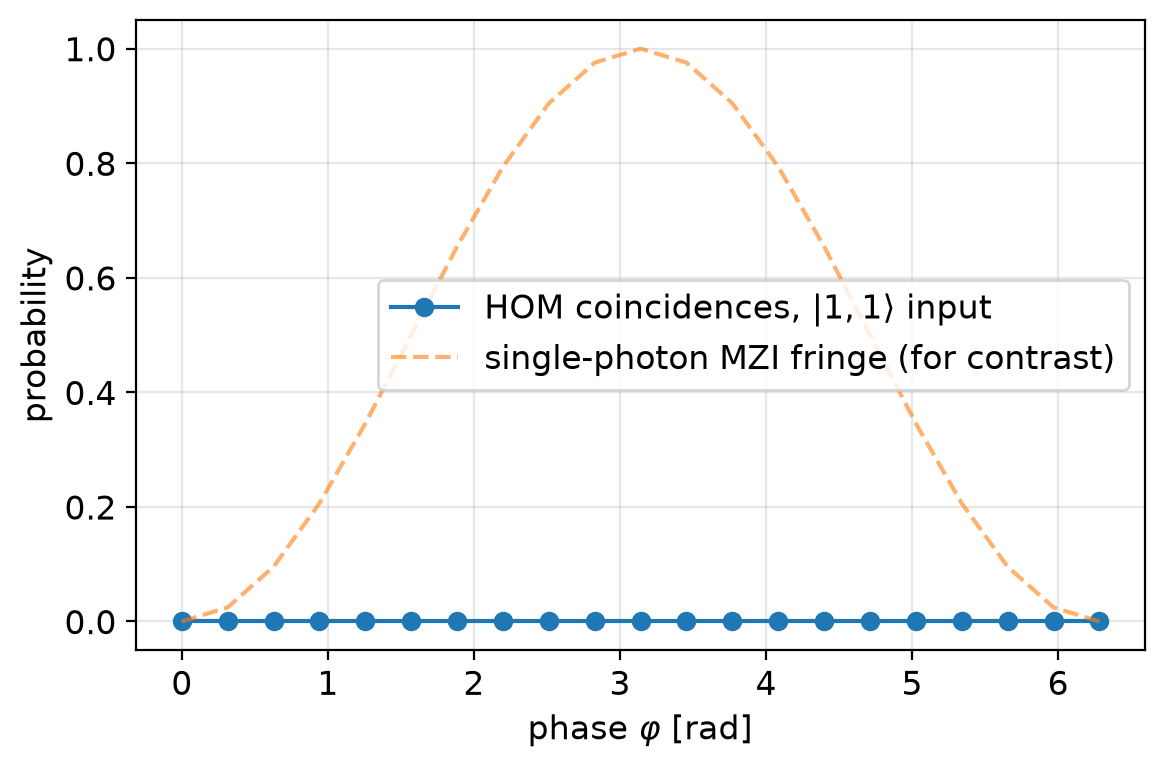

In [17]:
# Solution - Exercise 3
phis = np.linspace(0, 2 * np.pi, 21)
p_hom = []
for phi in phis:
    c = pcvl.Circuit(2) // (0, pcvl.PS(phi)) // pcvl.BS()  # phase BEFORE the BS
    proc = pcvl.Processor("SLOS", c)
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_hom.append(res.get(pcvl.BasicState([1, 1]), 0.0))

plt.plot(phis, p_hom, "o-", label=r"HOM coincidences, $|1,1\rangle$ input")
plt.plot(phis, np.sin(phis / 2) ** 2, "--", alpha=0.6,
         label="single-photon MZI fringe (for contrast)")
plt.ylim(-0.05, 1.05)
plt.xlabel(r"phase $\varphi$ [rad]")
plt.ylabel("probability")
plt.legend()
plt.tight_layout()
plt.show()
# Why flat: the two interfering processes are 'both photons transmitted'
# and 'both photons reflected'. In BOTH processes the same one photon
# passes the phase shifter exactly once, so both amplitudes acquire the
# same factor e^{i phi} - a global phase, invisible in probabilities.
# First-order interference compares paths of ONE photon; HOM compares
# two-photon histories. Different physics, different knobs.

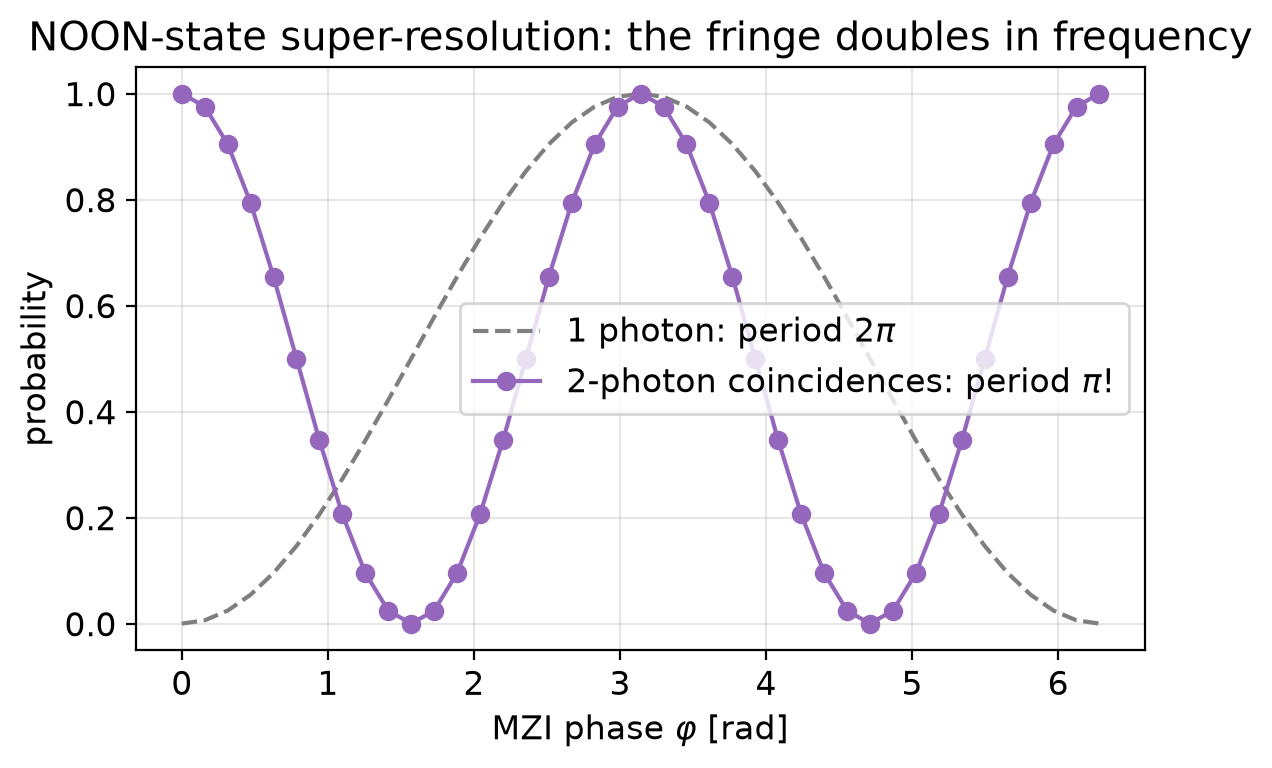

In [18]:
# Solution - Exercise 4
def mzi(phi: float) -> pcvl.Circuit:
    return pcvl.Circuit(2) // pcvl.BS() // (0, pcvl.PS(phi)) // pcvl.BS()

phis = np.linspace(0, 2 * np.pi, 41)
p_coinc, p_single = [], []
for phi in phis:
    # two photons: NOON state |2,0>-|0,2> forms inside the MZI
    proc = pcvl.Processor("SLOS", mzi(phi))
    proc.with_input(pcvl.BasicState([1, 1]))
    proc.min_detected_photons_filter(2)
    res = pcvl.algorithm.Sampler(proc).probs()["results"]
    p_coinc.append(res.get(pcvl.BasicState([1, 1]), 0.0))
    # one photon, for comparison
    proc1 = pcvl.Processor("SLOS", mzi(phi))
    proc1.with_input(pcvl.BasicState([1, 0]))
    proc1.min_detected_photons_filter(1)
    res1 = pcvl.algorithm.Sampler(proc1).probs()["results"]
    p_single.append(res1.get(pcvl.BasicState([1, 0]), 0.0))

plt.plot(phis, p_single, "--", color="tab:gray",
         label=r"1 photon: period $2\pi$")
plt.plot(phis, p_coinc, "o-", color="tab:purple",
         label=r"2-photon coincidences: period $\pi$!")
plt.xlabel(r"MZI phase $\varphi$ [rad]")
plt.ylabel("probability")
plt.title("NOON-state super-resolution: the fringe doubles in frequency")
plt.legend()
plt.tight_layout()
plt.show()
# The N=2 NOON state accumulates phase as e^{i 2 phi}: N-photon states
# reach the 1/N Heisenberg limit of phase estimation. Scaling N up is
# brutally hard (loss kills NOON states fast) - which is why LIGO uses
# squeezed light (Monday) rather than NOON states for the same goal.